In [34]:
# ДЗ 2
# Зашумить изображение при помощи шума гаусса, постоянного шума.
# Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.
# Выяснить, какой фильтр показал лучший результат фильтрации шума.

Моё решение:

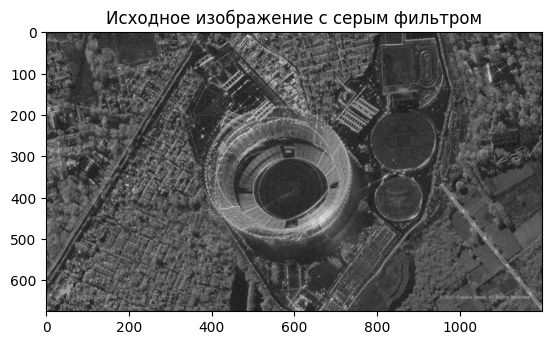

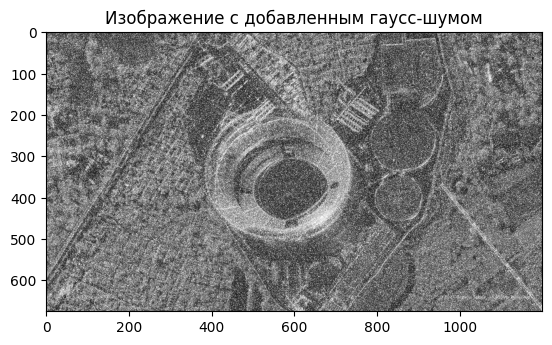

1. GAUSS NOISE
Gauss noise MSE and SSIM:
4226.025272839506 0.18728917567733971


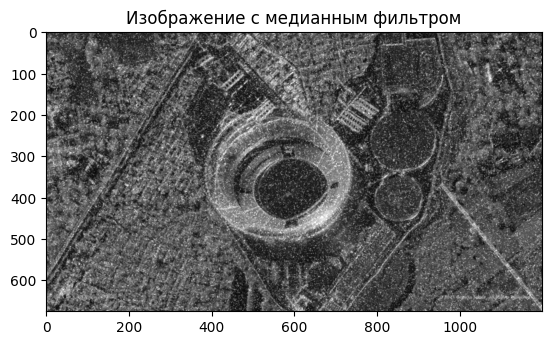

Median filter MSE and SSIM:
1035.5800814814816 0.4294396202069238


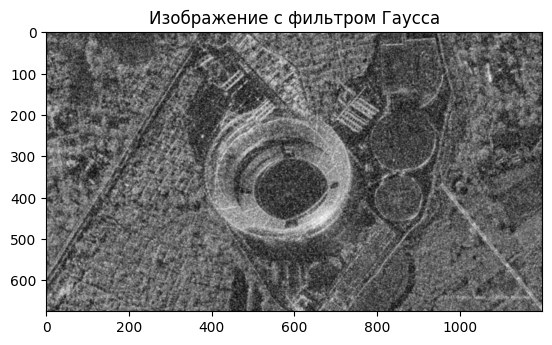

Gauss filter MSE and SSIM:
1761.8077950617285 0.4866425055601689


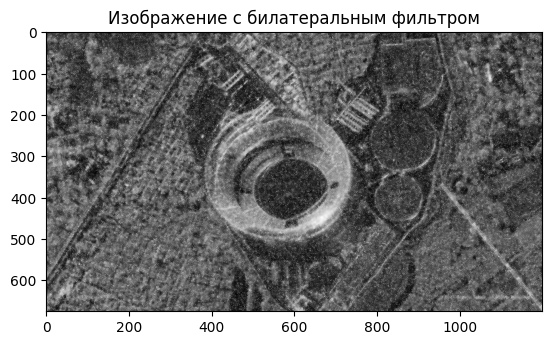

Bilateral filter MSE and SSIM:
1835.839639506173 0.31506140403628613


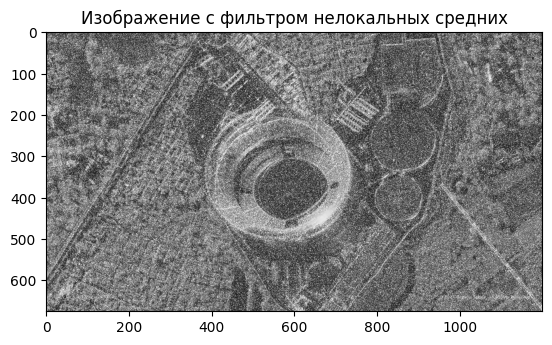

NLM filter MSE and SSIM:
4221.6409370370375 0.18772865263575678


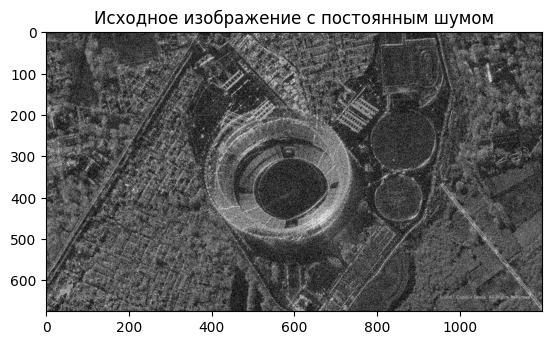


2. UNIFORM NOISE
Noise MSE and SSIM:
799.7980481481482 0.42137748579126577


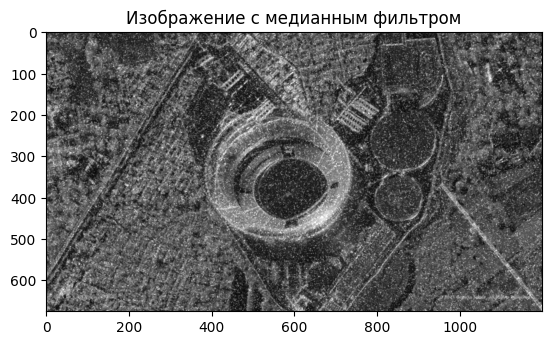

Median filter MSE and SSIM:
301.8037098765432 0.5502409498111909


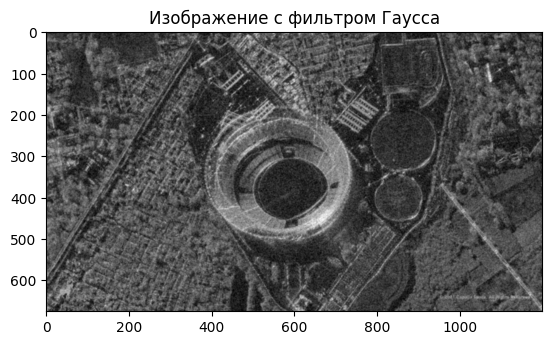

Gauss filter MSE and SSIM:
171.10723580246915 0.6850691594423085


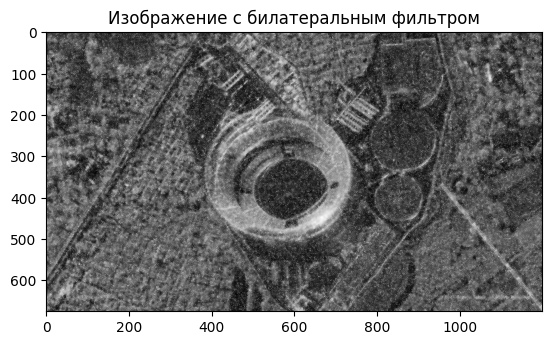

Bilateral filter MSE and SSIM:
207.85383209876542 0.6106065660475366


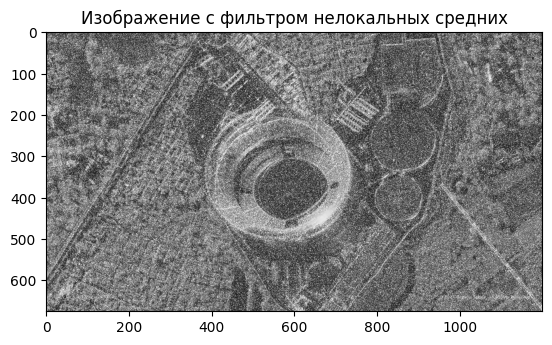

NLM filter MSE and SSIM:
265.2605814814815 0.6230730877802727


In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.title("Исходное изображение с серым фильтром")
plt.show()

# 1) Шум Гаусса
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")
plt.title("Изображение с добавленным гаусс-шумом")
plt.show()

mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print("1. GAUSS NOISE\nGauss noise MSE and SSIM:")
print(mse_gauss, ssim)

# Медианный фильтр
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
plt.imshow(image_gauss_median, cmap="gray")
plt.title("Изображение с медианным фильтром")
plt.show()

print("Median filter MSE and SSIM:")
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff11) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

# Фильтр Гаусса
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
plt.imshow(image_gauss_gauss, cmap="gray")
plt.title("Изображение с фильтром Гаусса")
plt.show()

print("Gauss filter MSE and SSIM:")
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff12) = structural_similarity(image_gray, image_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

# Билатеральный фильтр
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
plt.imshow(image_gauss_bilat, cmap="gray")
plt.title("Изображение с билатеральным фильтром")
plt.show()

print("Bilateral filter MSE and SSIM:")
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, diff13) = structural_similarity(image_gray, image_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

# Фильтр нелокальных средних
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
plt.imshow(image_gauss_nlm, cmap="gray")
plt.title("Изображение с фильтром нелокальных средних")
plt.show()

print("NLM filter MSE and SSIM:")
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, diff14) = structural_similarity(image_gray, image_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

# 2) Постоянный шум
noise_intensity = 50

uniform_noise = np.random.uniform(-noise_intensity, noise_intensity, image_gray.shape)
uniform_noise = uniform_noise.astype(np.int16)

image_uniform_noise = image_gray.astype(np.int16) + uniform_noise
image_uniform_noise = np.clip(image_uniform_noise, 0, 255).astype(np.uint8)

plt.imshow(image_uniform_noise, cmap="gray")
plt.title("Исходное изображение с постоянным шумом")
plt.show()

mse_noise = mean_squared_error(image_gray, image_uniform_noise)
(ssim, diff2) = structural_similarity(image_gray, image_uniform_noise, full=True)
print("\n2. UNIFORM NOISE\nNoise MSE and SSIM:")
print(mse_noise, ssim)

# Медианный фильтр
image_noise_median = cv2.medianBlur(image_uniform_noise, 3)
plt.imshow(image_gauss_median, cmap="gray")
plt.title("Изображение с медианным фильтром")
plt.show()

print("Median filter MSE and SSIM:")
mse_noise_median = mean_squared_error(image_gray, image_noise_median)
(ssim_noise_median, diff21) = structural_similarity(image_gray, image_noise_median, full=True)
print(mse_noise_median, ssim_noise_median)

# Фильтр Гаусса
image_noise_gauss = cv2.GaussianBlur(image_uniform_noise, (5, 5), 0)
plt.imshow(image_noise_gauss, cmap="gray")
plt.title("Изображение с фильтром Гаусса")
plt.show()

print("Gauss filter MSE and SSIM:")
mse_noise_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_noise_gauss, diff22) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_noise_gauss, ssim_noise_gauss)

# Билатеральный фильтр
image_noise_bilat = cv2.bilateralFilter(image_uniform_noise, 9, 75, 75)
plt.imshow(image_gauss_bilat, cmap="gray")
plt.title("Изображение с билатеральным фильтром")
plt.show()

print("Bilateral filter MSE and SSIM:")
mse_noise_bilat = mean_squared_error(image_gray, image_noise_bilat)
(ssim_noise_bilat, diff23) = structural_similarity(image_gray, image_noise_bilat, full=True)
print(mse_noise_bilat, ssim_noise_bilat)

# Фильтр нелокальных средних
image_noise_nlm = cv2.fastNlMeansDenoising(image_uniform_noise, h=20)
plt.imshow(image_gauss_nlm, cmap="gray")
plt.title("Изображение с фильтром нелокальных средних")
plt.show()

print("NLM filter MSE and SSIM:")
mse_noise_nlm = mean_squared_error(image_gray, image_noise_nlm)
(ssim_noise_nlm, diff24) = structural_similarity(image_gray, image_noise_nlm, full=True)
print(mse_noise_nlm, ssim_noise_nlm)
